In [1]:
from pathlib import Path
import numpy as np
import mne
import json
import os
from glob import glob
import re
from collections import defaultdict
from statsmodels.stats.multitest import multipletests
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
#Define subjects 
#migraine group
group_a_subjects = [
    'sub-001', 'sub-006', 'sub-010', 'sub-011', 'sub-017', 'sub-018', 'sub-022', 'sub-023', 'sub-025', 'sub-027', 'sub-028',
    'sub-033', 'sub-034', 'sub-039', 'sub-042', 'sub-047', 'sub-048', 'sub-053', 'sub-054', 'sub-055', 'sub-059', 'sub-062', 'sub-063', 'sub-074',
    'sub-077', 'sub-084', 'sub-088', 'sub-090', 'sub-091'
]
#control group
group_b_subjects = [
    'sub-002', 'sub-003', 'sub-004', 'sub-007', 'sub-008', 'sub-009', 'sub-012', 'sub-013', 'sub-014', 'sub-015', 'sub-016', 'sub-019', 'sub-021',
    'sub-024', 'sub-026', 'sub-029', 'sub-031', 'sub-035', 'sub-036', 'sub-037', 'sub-040', 'sub-041', 'sub-043', 'sub-045', 'sub-046', 
    'sub-050', 'sub-056', 'sub-057', 'sub-058', 'sub-060', 'sub-061', 'sub-064', 'sub-069', 'sub-071',
    'sub-072', 'sub-073', 'sub-075', 'sub-076', 'sub-078', 'sub-081', 'sub-082', 'sub-083', 'sub-085', 'sub-086', 'sub-087' 
]

In [3]:
#Put your sex coding here (numeric)

sex_map = {
    # Migraine group:
    'sub-001': '1', 'sub-006': '1', 'sub-010': '1', 'sub-011': '1', 'sub-017': '1', 'sub-018': '2', 'sub-022': '1', 'sub-023': '1',
    'sub-025': '1', 'sub-027': '1', 'sub-028': '1', 'sub-033': '1', 'sub-034': '1', 'sub-039': '1', 'sub-042': '1', 'sub-047': '2',
    'sub-048': '1', 'sub-053': '1', 'sub-054': '1', 'sub-055': '1', 'sub-059': '1', 'sub-062': '1', 'sub-063': '1', 'sub-074': '1', 
    'sub-077': '1', 'sub-084': '1', 'sub-088': '2', 'sub-090': '1', 'sub-091': '2',
    # Control group:
    'sub-002': '2', 'sub-003': '1', 'sub-004': '2', 'sub-007': '1', 'sub-008': '2', 'sub-009': '2', 'sub-012': '1', 'sub-013': '1',
    'sub-014': '1', 'sub-015': '1', 'sub-016': '1', 'sub-019': '2', 'sub-021': '1', 'sub-024': '1', 'sub-026': '1', 'sub-029': '1',
    'sub-031': '1', 'sub-035': '2', 'sub-036': '2', 'sub-037': '1', 'sub-040': '1', 'sub-041': '2', 'sub-043': '2', 'sub-045': '1',
    'sub-046': '2', 'sub-050': '1', 'sub-056': '2', 'sub-057': '2', 'sub-058': '1', 'sub-060': '2', 'sub-061': '2', 'sub-064': '2',
    'sub-069': '1', 'sub-071': '1', 'sub-072': '1', 'sub-073': '1', 'sub-075': '1', 'sub-076': '2', 'sub-078': '2', 'sub-081': '1',
    'sub-082': '1', 'sub-083': '1', 'sub-085': '1', 'sub-086': '1', 'sub-087': '1' 
}

def get_sex(sub_id):

    return float(sex_map[sub_id])

In [4]:
#Put your BDI and PSS scores here

bdi_map = {
    'sub-001': 18, 'sub-002': 25, 'sub-003': 18, 'sub-004': 11,
    'sub-006': 5,  'sub-007': 3,  'sub-008': 10, 'sub-009': 3,
    'sub-010': 7,  'sub-011': 10, 'sub-012': 5,  'sub-013': 10,
    'sub-014': 15, 'sub-015': 9,  'sub-016': 11, 'sub-017': 11,
    'sub-018': 11, 'sub-019': 7,  'sub-021': 14, 'sub-022': 29,
    'sub-023': 10, 'sub-024': 1,  'sub-025': 16, 'sub-026': 12,
    'sub-027': 18, 'sub-028': 25, 'sub-029': 10, 'sub-031': 13,
    'sub-033': 34, 'sub-034': 7,  'sub-035': 9,  'sub-036': 5,
    'sub-037': 35, 'sub-039': 13, 'sub-040': 5,  'sub-041': 17,
    'sub-042': 11, 'sub-043': 13, 'sub-045': 6,  'sub-046': 0,
    'sub-047': 23, 'sub-048': 14, 'sub-050': 10, 'sub-053': 17,
    'sub-054': 23, 'sub-055': 6,  'sub-056': 8,  'sub-057': 14,
    'sub-058': 0,  'sub-059': 23, 'sub-060': 2,  'sub-061': 9,
    'sub-062': 20, 'sub-063': 17, 'sub-064': 8,  'sub-069': 12,
    'sub-071': 11, 'sub-072': 2,  'sub-073': 6,  'sub-074': 10,
    'sub-075': 17, 'sub-076': 15, 'sub-077': 25, 'sub-078': 4,
    'sub-081': 13, 'sub-082': 7,  'sub-083': 20, 'sub-084': 12,
    'sub-085': 1,  'sub-086': 23, 'sub-087': 19, 'sub-088': 10,
    'sub-090': 5,  'sub-091': 8,
}

pss_map = {
    'sub-001': 24, 'sub-002': 30, 'sub-003': 19, 'sub-004': 10,
    'sub-006': 18, 'sub-007': 15, 'sub-008': 7,  'sub-009': 11,
    'sub-010': 13, 'sub-011': 16, 'sub-012': 12, 'sub-013': 8,
    'sub-014': 19, 'sub-015': 19, 'sub-016': 15, 'sub-017': 18,
    'sub-018': 16, 'sub-019': 9,  'sub-021': 21, 'sub-022': 29,
    'sub-023': 22, 'sub-024': 10, 'sub-025': 20, 'sub-026': 22,
    'sub-027': 26, 'sub-028': 26, 'sub-029': 23, 'sub-031': 10,
    'sub-033': 26, 'sub-034': 16, 'sub-035': 7,  'sub-036': 10,
    'sub-037': 24, 'sub-039': 22, 'sub-040': 17, 'sub-041': 21,
    'sub-042': 12, 'sub-043': 18, 'sub-045': 19, 'sub-046': 10,
    'sub-047': 22, 'sub-048': 17, 'sub-050': 24, 'sub-053': 19,
    'sub-054': 33, 'sub-055': 19, 'sub-056': 16, 'sub-057': 19,
    'sub-058': 12, 'sub-059': 25, 'sub-060': 8,  'sub-061': 20,
    'sub-062': 13, 'sub-063': 11, 'sub-064': 13, 'sub-069': 19,
    'sub-071': 14, 'sub-072': 11, 'sub-073': 13, 'sub-074': 13,
    'sub-075': 23, 'sub-076': 22, 'sub-077': 33, 'sub-078': 19,
    'sub-081': 21, 'sub-082': 22, 'sub-083': 24, 'sub-084': 25,
    'sub-085': 19, 'sub-086': 10, 'sub-087': 27, 'sub-088': 22,
    'sub-090': 8,  'sub-091': 15,
}

def get_bdi(sub_id):
    return float(bdi_map[sub_id])

def get_pss(sub_id):
    return float(pss_map[sub_id])

In [5]:
#ROIs

FRONTOCENTRAL_CHS = [
    'E13', 'E112', 'E29', 'E111', 'E28', 'E117', 'E6',
]
               
LEFT_TEMPORAL_CHS = [
    'E45', 'E44',
]

RIGHT_TEMPORAL_CHS = [
    'E114', 'E108',
]

RIGHT_PARIETAL_CHS = [ 
    'E92', 'E95', 'E85', 'E97',
]

LEFT_PARIETAL_CHS = [
    'E52', 'E60', 'E64',  'E51',
]

OCCIPITAL_CHS = [
    'E70', 'E83', 'E75', 'E67', 'E77', 'E65', 'E90', 'E72'
]

ROI_CHS = {
    "frontocentral": FRONTOCENTRAL_CHS,
    "leftparietal": LEFT_PARIETAL_CHS,
    "rightparietal": RIGHT_PARIETAL_CHS,
    "lefttemporal": LEFT_TEMPORAL_CHS,
    "righttemporal": RIGHT_TEMPORAL_CHS,
    "occipital": OCCIPITAL_CHS
}

In [6]:
#Load already segmented and preprocessed EEG files

BASE_DIR = Path("/media/ekstrandlab/eeg_backup/preprocessed/subjects")

# already segmented file stem
TASK_CORE = "task-neutraltrainingvideo_eeg_fil01to100_notch60_seg_bcd"

PREFERRED = f"_{TASK_CORE}_bcr_reref_ICA.set"
FALLBACK  = f"_{TASK_CORE}_reref_ICA.set"

def pick_set(eeglab_dir: Path, sub: str) -> Path | None:
    pref = eeglab_dir / f"{sub}{PREFERRED}"
    fall = eeglab_dir / f"{sub}{FALLBACK}"

    if pref.exists():
        return pref
    if fall.exists():
        return fall
    return None

raw_dict = {}

for sub_dir in sorted(BASE_DIR.glob("sub-*")):
    if not sub_dir.is_dir():
        continue

    sub = sub_dir.name
    eeglab_dir = sub_dir / "eeglab2"   # changed from eeglab to eeglab2
    if not eeglab_dir.exists():
        continue

    in_set = pick_set(eeglab_dir, sub)
    if in_set is None:
        print(f"{sub}: no matching .set file found")
        continue

    raw = mne.io.read_raw_eeglab(str(in_set), preload=True, verbose=False)
    raw_dict[sub] = raw
    print(f"{sub}: loaded {in_set.name}")


/tmp/ipykernel_10092/3369960164.py:37: RuntimeWarning: Limited 4 annotation(s) that were expanding outside the data range.
  raw = mne.io.read_raw_eeglab(str(in_set), preload=True, verbose=False)
/tmp/ipykernel_10092/3369960164.py:37: RuntimeWarning: The data contains 'boundary' events, indicating data discontinuities. Be cautious of filtering and epoching around these events.
  raw = mne.io.read_raw_eeglab(str(in_set), preload=True, verbose=False)


sub-001: loaded sub-001_task-neutraltrainingvideo_eeg_fil01to100_notch60_seg_bcd_bcr_reref_ICA.set


/tmp/ipykernel_10092/3369960164.py:37: RuntimeWarning: Limited 4 annotation(s) that were expanding outside the data range.
  raw = mne.io.read_raw_eeglab(str(in_set), preload=True, verbose=False)
/tmp/ipykernel_10092/3369960164.py:37: RuntimeWarning: The data contains 'boundary' events, indicating data discontinuities. Be cautious of filtering and epoching around these events.
  raw = mne.io.read_raw_eeglab(str(in_set), preload=True, verbose=False)


sub-002: loaded sub-002_task-neutraltrainingvideo_eeg_fil01to100_notch60_seg_bcd_bcr_reref_ICA.set


/tmp/ipykernel_10092/3369960164.py:37: RuntimeWarning: Limited 4 annotation(s) that were expanding outside the data range.
  raw = mne.io.read_raw_eeglab(str(in_set), preload=True, verbose=False)
/tmp/ipykernel_10092/3369960164.py:37: RuntimeWarning: The data contains 'boundary' events, indicating data discontinuities. Be cautious of filtering and epoching around these events.
  raw = mne.io.read_raw_eeglab(str(in_set), preload=True, verbose=False)


...

/tmp/ipykernel_10092/3369960164.py:37: RuntimeWarning: Limited 4 annotation(s) that were expanding outside the data range.
  raw = mne.io.read_raw_eeglab(str(in_set), preload=True, verbose=False)
/tmp/ipykernel_10092/3369960164.py:37: RuntimeWarning: The data contains 'boundary' events, indicating data discontinuities. Be cautious of filtering and epoching around these events.
  raw = mne.io.read_raw_eeglab(str(in_set), preload=True, verbose=False)


sub-089: loaded sub-089_task-neutraltrainingvideo_eeg_fil01to100_notch60_seg_bcd_bcr_reref_ICA.set


/tmp/ipykernel_10092/3369960164.py:37: RuntimeWarning: Limited 4 annotation(s) that were expanding outside the data range.
  raw = mne.io.read_raw_eeglab(str(in_set), preload=True, verbose=False)
/tmp/ipykernel_10092/3369960164.py:37: RuntimeWarning: The data contains 'boundary' events, indicating data discontinuities. Be cautious of filtering and epoching around these events.
  raw = mne.io.read_raw_eeglab(str(in_set), preload=True, verbose=False)


sub-090: loaded sub-090_task-neutraltrainingvideo_eeg_fil01to100_notch60_seg_bcd_bcr_reref_ICA.set
sub-091: loaded sub-091_task-neutraltrainingvideo_eeg_fil01to100_notch60_seg_bcd_bcr_reref_ICA.set


/tmp/ipykernel_10092/3369960164.py:37: RuntimeWarning: Limited 3 annotation(s) that were expanding outside the data range.
  raw = mne.io.read_raw_eeglab(str(in_set), preload=True, verbose=False)
/tmp/ipykernel_10092/3369960164.py:37: RuntimeWarning: The data contains 'boundary' events, indicating data discontinuities. Be cautious of filtering and epoching around these events.
  raw = mne.io.read_raw_eeglab(str(in_set), preload=True, verbose=False)


In [7]:
#Whole-scalp/global bandpower from already-segmented eeglab2 .set files
#Welch PSD, 4 s windows, 50% overlap, zero-padding,
#predefined gamma band, averaged across all EEG electrodes.

base_dir = "/media/ekstrandlab/eeg_backup/preprocessed/subjects"

subjects = group_a_subjects + group_b_subjects

BANDS = {
    "gamma": (30, 100),
}

FMIN, FMAX = BANDS["gamma"]

TASK_FILE = "task-neutraltrainingvideo_eeg_fil01to100_notch60_seg_bcd_bcr_reref_ICA.set"


def find_input_set(sub_id):
    eeglab2_dir = os.path.join(base_dir, sub_id, "eeglab2")
    in_set = os.path.join(eeglab2_dir, f"{sub_id}_{TASK_FILE}")

    if not os.path.exists(in_set):
        raise FileNotFoundError(f"Missing file for {sub_id}: {in_set}")

    return in_set


def compute_and_save_global_bandpower(sub_id):
    in_set = find_input_set(sub_id)

    raw = mne.io.read_raw_eeglab(in_set, preload=False, verbose=False)

    sfreq = raw.info["sfreq"]

    n_per_seg = int(sfreq * 4)          # 4 s windows
    n_overlap = int(n_per_seg * 0.5)    # 50% overlap
    n_fft = 8192                        # zero-padding because n_fft > n_per_seg

    spectrum = raw.compute_psd(
        method="welch",
        fmin=FMIN,
        fmax=FMAX,
        n_fft=n_fft,
        n_per_seg=n_per_seg,
        n_overlap=n_overlap,
        window="hann",
        picks="eeg",
        verbose=False,
    )

    psd = spectrum.get_data()  # channels x frequencies
    freqs = spectrum.freqs

    # Compute power at each electrode, then average across all electrodes
    mean_psd_all_electrodes = psd.mean(axis=0)

    global_bandpower = {}

    for band, (f1, f2) in BANDS.items():
        idx = (freqs >= f1) & (freqs <= f2)

        if not np.any(idx):
            global_bandpower[band] = np.nan
        else:
            global_bandpower[band] = float(mean_psd_all_electrodes[idx].mean())

    out = {
        "subject": sub_id,
        "input_file": os.path.basename(in_set),
        "sfreq": float(sfreq),
        "method": "welch",
        "freq_range": [FMIN, FMAX],
        "n_fft": int(n_fft),
        "n_per_seg": int(n_per_seg),
        "n_overlap": int(n_overlap),
        "window": "hann",
        "frequency_bands": BANDS,
        "averaging": "PSD computed at each EEG electrode, then averaged across all EEG electrodes before frequency-band averaging",
        "global_bandpower_linear": global_bandpower,
    }

    out_json = os.path.splitext(in_set)[0] + "_global_bandpower_gamma.json"

    with open(out_json, "w") as f:
        json.dump(out, f, indent=2)

    return out_json


print("Computing whole-scalp/global bandpower JSONs...")

written = 0

for sub in subjects:
    try:
        out_path = compute_and_save_global_bandpower(sub)
        print(f"{sub}: wrote {os.path.basename(out_path)}")
        written += 1
    except Exception as e:
        print(f"{sub}: SKIPPED ({e})")

print(f"\nDone. Wrote {written}/{len(subjects)} global bandpower JSON files.")

Computing whole-scalp/global bandpower JSONs...


/tmp/ipykernel_1101746/1983480491.py:31: RuntimeWarning: Limited 4 annotation(s) that were expanding outside the data range.
  raw = mne.io.read_raw_eeglab(in_set, preload=False, verbose=False)
/tmp/ipykernel_1101746/1983480491.py:31: RuntimeWarning: The data contains 'boundary' events, indicating data discontinuities. Be cautious of filtering and epoching around these events.
  raw = mne.io.read_raw_eeglab(in_set, preload=False, verbose=False)


sub-001: wrote sub-001_task-neutraltrainingvideo_eeg_fil01to100_notch60_seg_bcd_bcr_reref_ICA_global_bandpower_gamma.json


/tmp/ipykernel_1101746/1983480491.py:31: RuntimeWarning: Limited 3 annotation(s) that were expanding outside the data range.
  raw = mne.io.read_raw_eeglab(in_set, preload=False, verbose=False)
/tmp/ipykernel_1101746/1983480491.py:31: RuntimeWarning: The data contains 'boundary' events, indicating data discontinuities. Be cautious of filtering and epoching around these events.
  raw = mne.io.read_raw_eeglab(in_set, preload=False, verbose=False)


sub-006: wrote sub-006_task-neutraltrainingvideo_eeg_fil01to100_notch60_seg_bcd_bcr_reref_ICA_global_bandpower_gamma.json


...

sub-085: wrote sub-085_task-neutraltrainingvideo_eeg_fil01to100_notch60_seg_bcd_bcr_reref_ICA_global_bandpower_gamma.json


/tmp/ipykernel_1101746/1983480491.py:31: RuntimeWarning: Limited 4 annotation(s) that were expanding outside the data range.
  raw = mne.io.read_raw_eeglab(in_set, preload=False, verbose=False)
/tmp/ipykernel_1101746/1983480491.py:31: RuntimeWarning: The data contains 'boundary' events, indicating data discontinuities. Be cautious of filtering and epoching around these events.
  raw = mne.io.read_raw_eeglab(in_set, preload=False, verbose=False)


sub-086: wrote sub-086_task-neutraltrainingvideo_eeg_fil01to100_notch60_seg_bcd_bcr_reref_ICA_global_bandpower_gamma.json


/tmp/ipykernel_1101746/1983480491.py:31: RuntimeWarning: Limited 3 annotation(s) that were expanding outside the data range.
  raw = mne.io.read_raw_eeglab(in_set, preload=False, verbose=False)
/tmp/ipykernel_1101746/1983480491.py:31: RuntimeWarning: The data contains 'boundary' events, indicating data discontinuities. Be cautious of filtering and epoching around these events.
  raw = mne.io.read_raw_eeglab(in_set, preload=False, verbose=False)


sub-087: wrote sub-087_task-neutraltrainingvideo_eeg_fil01to100_notch60_seg_bcd_bcr_reref_ICA_global_bandpower_gamma.json

Done. Wrote 74/74 global bandpower JSON files.


In [8]:
#Freedman-Lane permutation testing for whole-scalp/global bandpower
#Migraine vs control, controlling for sex, BDI, and PSS
#Two-tailed p-value

base_dir = "/media/ekstrandlab/eeg_backup/preprocessed/subjects"

N_PERM = 10000
RANDOM_SEED = 42

bands = ["gamma"]

TASK_CORE = "task-neutraltrainingvideo_eeg_fil01to100_notch60_seg_bcd_bcr_reref_ICA"
JSON_SUFFIX = "_global_bandpower_gamma.json"

rng = np.random.default_rng(RANDOM_SEED)

rows = []

#Load data

for sub in group_a_subjects:

    json_path = os.path.join(
        base_dir,
        sub,
        "eeglab2",
        f"{sub}_{TASK_CORE}{JSON_SUFFIX}"
    )

    if not os.path.exists(json_path):
        print(f"{sub}: missing global bandpower JSON")
        continue

    with open(json_path, "r") as f:
        dat = json.load(f)

    row = {
        "subject": sub,
        "group": 1,  # migraine
        "sex": float(sex_map[sub]),
        "bdi": get_bdi(sub),
        "pss": get_pss(sub),
    }

    for band in bands:
        row[band] = dat["global_bandpower_linear"][band]

    rows.append(row)


for sub in group_b_subjects:

    json_path = os.path.join(
        base_dir,
        sub,
        "eeglab2",
        f"{sub}_{TASK_CORE}{JSON_SUFFIX}"
    )

    if not os.path.exists(json_path):
        print(f"{sub}: missing global bandpower JSON")
        continue

    with open(json_path, "r") as f:
        dat = json.load(f)

    row = {
        "subject": sub,
        "group": 0,  # control
        "sex": float(sex_map[sub]),
        "bdi": get_bdi(sub),
        "pss": get_pss(sub),
    }

    for band in bands:
        row[band] = dat["global_bandpower_linear"][band]

    rows.append(row)

df = pd.DataFrame(rows)

print(df.head())
print(f"\nLoaded {len(df)} subjects")

#Freedman-lane permutation function

def freedman_lane_group_test(y, group, sex, bdi, pss, n_perm, rng=None):

    if rng is None:
        rng = np.random.default_rng()

    y = np.asarray(y, dtype=float)
    group = np.asarray(group, dtype=float)
    sex = np.asarray(sex, dtype=float)
    bdi = np.asarray(bdi, dtype=float)
    pss = np.asarray(pss, dtype=float)

    valid = (
        np.isfinite(y) &
        np.isfinite(group) &
        np.isfinite(sex) &
        np.isfinite(bdi) &
        np.isfinite(pss)
    )

    y = y[valid]
    group = group[valid]
    sex = sex[valid]
    bdi = bdi[valid]
    pss = pss[valid]

    #Reduced model: covariates only
    X_reduced = np.column_stack([
        np.ones(len(y)),
        sex,
        bdi,
        pss
    ])

    #Full model: covariates + group
    X_full = np.column_stack([
        np.ones(len(y)),
        sex,
        bdi,
        pss,
        group
    ])

    #Observed group beta
    beta_full = np.linalg.lstsq(X_full, y, rcond=None)[0]
    observed_group_beta = beta_full[-1]

    #Reduced model fit
    beta_reduced = np.linalg.lstsq(X_reduced, y, rcond=None)[0]
    fitted_reduced = X_reduced @ beta_reduced
    residuals = y - fitted_reduced

    perm_betas = np.zeros(n_perm)

    #Freedman-Lane permutations
    for i in range(n_perm):

        permuted_residuals = residuals[rng.permutation(len(residuals))]

        y_perm = fitted_reduced + permuted_residuals

        beta_perm = np.linalg.lstsq(X_full, y_perm, rcond=None)[0]

        perm_betas[i] = beta_perm[-1]

    #Two-tailed permutation p-value
    p_two_tailed = (
        np.sum(np.abs(perm_betas) >= np.abs(observed_group_beta)) + 1
    ) / (n_perm + 1)

    return observed_group_beta, p_two_tailed

# Run test within gamma band

results = []

for band in bands:

    beta_group, p_uncorrected = freedman_lane_group_test(
        y=df[band].values,
        group=df["group"].values,
        sex=df["sex"].values,
        bdi=df["bdi"].values,
        pss=df["pss"].values,
        n_perm=N_PERM,
        rng=rng
    )

    results.append({
        "band": band,
        "beta_group_migraine_minus_control": beta_group,
        "p_uncorrected": p_uncorrected,
    })

results_df = pd.DataFrame(results)
print("\nGlobal gamma power permutation results controlling for sex, BDI, and PSS:")
print(results_df.to_string(index=False))

#Save results

out_csv = os.path.join(
    base_dir,
    "neutraltrainingvideo_global_power_freedman_lane_sex_bdi_pss_results_gamma.csv"
)

results_df.to_csv(out_csv, index=False)
print(f"\nSaved results to:\n{out_csv}")

   subject  group  sex   bdi   pss         gamma
0  sub-001      1  1.0  18.0  24.0  2.524204e-13
1  sub-006      1  1.0   5.0  18.0  1.631983e-13
2  sub-010      1  1.0   7.0  13.0  1.598975e-13
3  sub-011      1  1.0  10.0  16.0  5.259701e-14
4  sub-017      1  1.0  11.0  18.0  1.396006e-13

Loaded 74 subjects

Global gamma power permutation results controlling for sex, BDI, and PSS:
 band  beta_group_migraine_minus_control  p_uncorrected
gamma                      -5.696743e-14       0.065293

Saved results to:
/media/ekstrandlab/eeg_backup/preprocessed/subjects/neutraltrainingvideo_global_power_freedman_lane_sex_bdi_pss_results_gamma.csv


In [9]:
# ROI bandpower from already-segmented eeglab2 .set files
# Uses existing ROI_CHS already defined above

base_dir = "/media/ekstrandlab/eeg_backup/preprocessed/subjects"

subjects = group_a_subjects + group_b_subjects

BANDS = {
    "gamma": (30,100),
}

FMIN, FMAX = BANDS["gamma"]

TASK_FILE = "task-neutraltrainingvideo_eeg_fil01to100_notch60_seg_bcd_bcr_reref_ICA.set"

def find_input_set(sub_id):
    eeglab2_dir = os.path.join(base_dir, sub_id, "eeglab2")
    in_set = os.path.join(eeglab2_dir, f"{sub_id}_{TASK_FILE}")

    if not os.path.exists(in_set):
        raise FileNotFoundError(f"Missing file for {sub_id}: {in_set}")

    return in_set


def compute_and_save_roi_bandpower(sub_id):
    in_set = find_input_set(sub_id)

    raw = mne.io.read_raw_eeglab(
        in_set,
        preload=False,
        verbose=False
    )

    sfreq = raw.info["sfreq"]

    n_per_seg = int(sfreq * 4)
    n_overlap = int(n_per_seg * 0.5)
    n_fft = 8192

    roi_bandpower = {}

    for roi_name, roi_chs in ROI_CHS.items():

        available_chs = [ch for ch in roi_chs if ch in raw.ch_names]

        if len(available_chs) < 2:
            roi_bandpower[roi_name] = {band: np.nan for band in BANDS}
            continue

        spectrum = raw.compute_psd(
            method="welch",
            fmin=FMIN,
            fmax=FMAX,
            n_fft=n_fft,
            n_per_seg=n_per_seg,
            n_overlap=n_overlap,
            window="hann",
            picks=available_chs,
            verbose=False,
        )

        psd = spectrum.get_data()
        freqs = spectrum.freqs

        mean_psd_roi = psd.mean(axis=0)

        roi_bandpower[roi_name] = {}

        for band, (f1, f2) in BANDS.items():
            idx = (freqs >= f1) & (freqs < f2)

            if not np.any(idx):
                roi_bandpower[roi_name][band] = np.nan
            else:
                roi_bandpower[roi_name][band] = float(mean_psd_roi[idx].mean())

    out = {
        "subject": sub_id,
        "input_file": os.path.basename(in_set),
        "sfreq": float(sfreq),
        "method": "welch",
        "freq_range": [FMIN, FMAX],
        "n_fft": int(n_fft),
        "n_per_seg": int(n_per_seg),
        "n_overlap": int(n_overlap),
        "window": "hann",
        "frequency_bands": BANDS,
        "roi_names": list(ROI_CHS.keys()),
        "averaging": "PSD computed within each ROI, averaged across ROI electrodes, then averaged within frequency band",
        "roi_bandpower_linear": roi_bandpower,
    }

    out_json = os.path.splitext(in_set)[0] + "_hemi_roi_bandpower_gamma.json"

    with open(out_json, "w") as f:
        json.dump(out, f, indent=2)

    return out_json


print("Computing ROI bandpower JSONs...")

written = 0

for sub in subjects:
    try:
        out_path = compute_and_save_roi_bandpower(sub)
        print(f"{sub}: wrote {os.path.basename(out_path)}")
        written += 1
    except Exception as e:
        print(f"{sub}: SKIPPED ({e})")

print(f"\nDone. Wrote {written}/{len(subjects)} ROI bandpower JSON files.")


Computing ROI bandpower JSONs...


/tmp/ipykernel_1101746/3082376890.py:29: RuntimeWarning: Limited 4 annotation(s) that were expanding outside the data range.
  raw = mne.io.read_raw_eeglab(
/tmp/ipykernel_1101746/3082376890.py:29: RuntimeWarning: The data contains 'boundary' events, indicating data discontinuities. Be cautious of filtering and epoching around these events.
  raw = mne.io.read_raw_eeglab(


sub-001: wrote sub-001_task-neutraltrainingvideo_eeg_fil01to100_notch60_seg_bcd_bcr_reref_ICA_hemi_roi_bandpower_gamma.json


/tmp/ipykernel_1101746/3082376890.py:29: RuntimeWarning: Limited 3 annotation(s) that were expanding outside the data range.
  raw = mne.io.read_raw_eeglab(
/tmp/ipykernel_1101746/3082376890.py:29: RuntimeWarning: The data contains 'boundary' events, indicating data discontinuities. Be cautious of filtering and epoching around these events.
  raw = mne.io.read_raw_eeglab(


sub-006: wrote sub-006_task-neutraltrainingvideo_eeg_fil01to100_notch60_seg_bcd_bcr_reref_ICA_hemi_roi_bandpower_gamma.json


...

sub-085: wrote sub-085_task-neutraltrainingvideo_eeg_fil01to100_notch60_seg_bcd_bcr_reref_ICA_hemi_roi_bandpower_gamma.json


/tmp/ipykernel_1101746/3082376890.py:29: RuntimeWarning: Limited 4 annotation(s) that were expanding outside the data range.
  raw = mne.io.read_raw_eeglab(
/tmp/ipykernel_1101746/3082376890.py:29: RuntimeWarning: The data contains 'boundary' events, indicating data discontinuities. Be cautious of filtering and epoching around these events.
  raw = mne.io.read_raw_eeglab(


sub-086: wrote sub-086_task-neutraltrainingvideo_eeg_fil01to100_notch60_seg_bcd_bcr_reref_ICA_hemi_roi_bandpower_gamma.json


/tmp/ipykernel_1101746/3082376890.py:29: RuntimeWarning: Limited 3 annotation(s) that were expanding outside the data range.
  raw = mne.io.read_raw_eeglab(
/tmp/ipykernel_1101746/3082376890.py:29: RuntimeWarning: The data contains 'boundary' events, indicating data discontinuities. Be cautious of filtering and epoching around these events.
  raw = mne.io.read_raw_eeglab(


sub-087: wrote sub-087_task-neutraltrainingvideo_eeg_fil01to100_notch60_seg_bcd_bcr_reref_ICA_hemi_roi_bandpower_gamma.json

Done. Wrote 74/74 ROI bandpower JSON files.


In [10]:
#Freedman-Lane permutation testing for ROI bandpower
#Migraine vs control, controlling for sex, BDI, and PSS
#Two-tailed p-values; BH-FDR correction across ROIs within the gamma frequency band

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)
pd.set_option("display.max_colwidth", None)

base_dir = "/media/ekstrandlab/eeg_backup/preprocessed/subjects"

N_PERM = 10000
RANDOM_SEED = 42

bands = ["gamma"]
rois = ["frontocentral", "rightparietal", "leftparietal", "righttemporal", "lefttemporal", "occipital"]

TASK_CORE = "task-neutraltrainingvideo_eeg_fil01to100_notch60_seg_bcd_bcr_reref_ICA"
JSON_SUFFIX = "_hemi_roi_bandpower_gamma.json"

rng = np.random.default_rng(RANDOM_SEED)

rows = []

#Load data

for sub in group_a_subjects:

    json_path = os.path.join(
        base_dir,
        sub,
        "eeglab2",
        f"{sub}_{TASK_CORE}{JSON_SUFFIX}"
    )

    if not os.path.exists(json_path):
        print(f"{sub}: missing ROI bandpower JSON")
        continue

    with open(json_path, "r") as f:
        dat = json.load(f)

    row = {
        "subject": sub,
        "group": 1,  # migraine
        "sex": float(sex_map[sub]),
        "bdi": get_bdi(sub),
        "pss": get_pss(sub),
    }

    for roi in rois:
        for band in bands:
            row[f"{roi}_{band}"] = dat["roi_bandpower_linear"][roi][band]

    rows.append(row)


for sub in group_b_subjects:

    json_path = os.path.join(
        base_dir,
        sub,
        "eeglab2",
        f"{sub}_{TASK_CORE}{JSON_SUFFIX}"
    )

    if not os.path.exists(json_path):
        print(f"{sub}: missing ROI bandpower JSON")
        continue

    with open(json_path, "r") as f:
        dat = json.load(f)

    row = {
        "subject": sub,
        "group": 0,  # control
        "sex": float(sex_map[sub]),
        "bdi": get_bdi(sub),
        "pss": get_pss(sub),
    }

    for roi in rois:
        for band in bands:
            row[f"{roi}_{band}"] = dat["roi_bandpower_linear"][roi][band]

    rows.append(row)

df = pd.DataFrame(rows)

print(df.head())
print(f"\nLoaded {len(df)} subjects")

#Freedman-lane permutation function

def freedman_lane_group_test(y, group, sex, bdi, pss, n_perm, rng=None):

    if rng is None:
        rng = np.random.default_rng()

    y = np.asarray(y, dtype=float)
    group = np.asarray(group, dtype=float)
    sex = np.asarray(sex, dtype=float)
    bdi = np.asarray(bdi, dtype=float)
    pss = np.asarray(pss, dtype=float)

    valid = (
        np.isfinite(y) &
        np.isfinite(group) &
        np.isfinite(sex) &
        np.isfinite(bdi) &
        np.isfinite(pss)
    )

    y = y[valid]
    group = group[valid]
    sex = sex[valid]
    bdi = bdi[valid]
    pss = pss[valid]

    #Reduced model: covariates only
    X_reduced = np.column_stack([
        np.ones(len(y)),
        sex,
        bdi,
        pss
    ])

    #Full model: covariates + group
    X_full = np.column_stack([
        np.ones(len(y)),
        sex,
        bdi,
        pss,
        group
    ])

    beta_full = np.linalg.lstsq(X_full, y, rcond=None)[0]
    observed_group_beta = beta_full[-1]

    beta_reduced = np.linalg.lstsq(X_reduced, y, rcond=None)[0]
    fitted_reduced = X_reduced @ beta_reduced
    residuals = y - fitted_reduced

    perm_betas = np.zeros(n_perm)

    for i in range(n_perm):
        permuted_residuals = residuals[rng.permutation(len(residuals))]
        y_perm = fitted_reduced + permuted_residuals

        beta_perm = np.linalg.lstsq(X_full, y_perm, rcond=None)[0]
        perm_betas[i] = beta_perm[-1]

    p_two_tailed = (
        np.sum(np.abs(perm_betas) >= np.abs(observed_group_beta)) + 1
    ) / (n_perm + 1)

    return observed_group_beta, p_two_tailed

#Run tests for each ROI

results = []

for band in bands:
    for roi in rois:

        variable = f"{roi}_{band}"

        beta_group, p_uncorrected = freedman_lane_group_test(
            y=df[variable].values,
            group=df["group"].values,
            sex=df["sex"].values,
            bdi=df["bdi"].values,
            pss=df["pss"].values,
            n_perm=N_PERM,
            rng=rng
        )

        results.append({
            "band": band,
            "roi": roi,
            "beta_group_migraine_minus_control": beta_group,
            "p_uncorrected": p_uncorrected,
        })

results_df = pd.DataFrame(results)

#FDR correction across ROIs within the gamma frequency band

results_df["p_fdr"] = np.nan
results_df["significant_fdr"] = False

for band in bands:
    band_mask = results_df["band"] == band

    reject, p_fdr, _, _ = multipletests(
        results_df.loc[band_mask, "p_uncorrected"],
        method="fdr_bh"
    )

    results_df.loc[band_mask, "p_fdr"] = p_fdr
    results_df.loc[band_mask, "significant_fdr"] = reject

#Order and display results

results_df["band"] = pd.Categorical(results_df["band"], categories=bands, ordered=True)
results_df["roi"] = pd.Categorical(results_df["roi"], categories=rois, ordered=True)

results_df = results_df.sort_values(["band", "roi"]).reset_index(drop=True)

results_df = results_df[
    [
        "band",
        "roi",
        "beta_group_migraine_minus_control",
        "p_uncorrected",
        "p_fdr",
        "significant_fdr",
    ]
]

print("\nROI power permutation results controlling for sex, BDI, and PSS:")
print(results_df.to_string(index=False))

#Save results

out_csv = os.path.join(
    base_dir,
    "neutraltrainingvideo_roi_power_freedman_lane_sex_bdi_pss_fdr_across_rois_results_hemi_gamma.csv"
)

results_df.to_csv(out_csv, index=False)

print(f"\nSaved results to:\n{out_csv}")

   subject  group  sex   bdi   pss  frontocentral_gamma  rightparietal_gamma  leftparietal_gamma  righttemporal_gamma  lefttemporal_gamma  occipital_gamma
0  sub-001      1  1.0  18.0  24.0         1.022784e-13         9.091544e-14        2.327122e-13         1.662769e-13        4.204863e-13     1.321359e-13
1  sub-006      1  1.0   5.0  18.0         4.268080e-14         5.125825e-14        7.912551e-14         5.381122e-14        1.426820e-13     1.660491e-13
2  sub-010      1  1.0   7.0  13.0         1.158540e-13         6.300060e-14        6.859221e-14         2.220180e-13        2.846734e-13     5.123157e-14
3  sub-011      1  1.0  10.0  16.0         2.328917e-14         2.402091e-14        2.202761e-14         6.291115e-14        4.409054e-14     4.016950e-14
4  sub-017      1  1.0  11.0  18.0         7.909817e-14         1.014595e-13        7.435314e-14         4.024254e-13        2.664760e-13     6.460719e-14

Loaded 74 subjects

ROI power permutation results controlling for sex


Loaded raw gamma values:
                        count          mean           std
roi           group                                      
frontocentral Control      45  1.268324e-13  1.341497e-13
              Migraine     29  6.624823e-14  4.188818e-14
leftparietal  Control      45  9.572506e-14  7.564551e-14
              Migraine     29  8.411407e-14  5.896515e-14
lefttemporal  Control      45  2.231059e-13  2.742713e-13
              Migraine     29  1.865893e-13  1.118022e-13
occipital     Control      45  9.754258e-14  6.708274e-14
              Migraine     29  1.264929e-13  1.316583e-13
rightparietal Control      45  1.050996e-13  8.521243e-14
              Migraine     29  7.661889e-14  5.177576e-14
righttemporal Control      45  3.504605e-13  5.007933e-13
              Migraine     29  1.441785e-13  1.046240e-13

Adjusted alpha values:
              roi     group      mean       sem   n
0   frontocentral   Control  1.314583  0.180500  45
1   frontocentral  Migraine  0.590

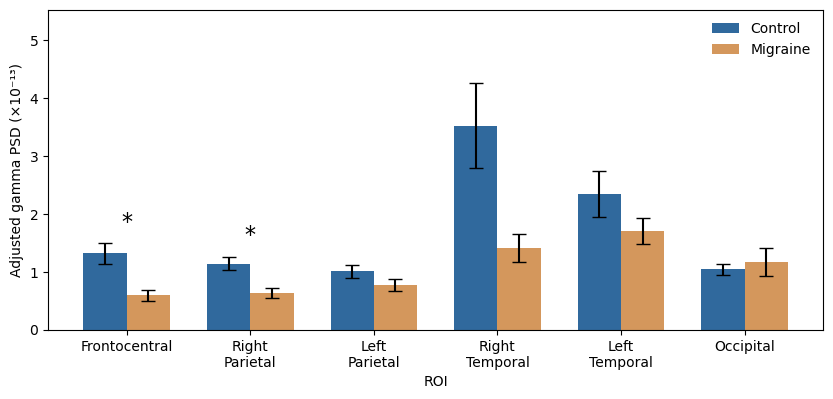

In [12]:
#Create plot of ROI gamma results

base_dir = "/media/ekstrandlab/eeg_backup/preprocessed/subjects"

TASK_CORE = "task-neutraltrainingvideo_eeg_fil01to100_notch60_seg_bcd_bcr_reref_ICA"
JSON_SUFFIX = "_hemi_roi_bandpower_gamma.json"

ROI_ORDER = [
    "frontocentral",
    "rightparietal",
    "leftparietal",
    "righttemporal",
    "lefttemporal",
    "occipital",
]

SIGNIFICANT_ROIS = [
    "frontocentral",
    "rightparietal",
]

rows = []

for sub in group_a_subjects + group_b_subjects:
    json_path = os.path.join(
        base_dir,
        sub,
        "eeglab2",
        f"{sub}_{TASK_CORE}{JSON_SUFFIX}"
    )

    if not os.path.exists(json_path):
        print(f"Missing: {json_path}")
        continue

    with open(json_path, "r") as f:
        dat = json.load(f)

    for roi in ROI_ORDER:
        rows.append({
            "subject": sub,
            "roi": roi,
            "group": "Migraine" if sub in group_a_subjects else "Control",
            "group_num": 1 if sub in group_a_subjects else 0,
            "sex": get_sex(sub),
            "bdi": get_bdi(sub),
            "pss": get_pss(sub),
            "gamma": dat["roi_bandpower_linear"][roi]["gamma"]
        })

df = pd.DataFrame(rows)

print("\nLoaded raw gamma values:")
print(df.groupby(["roi", "group"])["gamma"].agg(["count", "mean", "std"]))

adjusted_rows = []

for roi in ROI_ORDER:
    d = df[df["roi"] == roi].copy()
    y = d["gamma"].values.astype(float)
    group = d["group_num"].values.astype(float)
    sex = d["sex"].values.astype(float)
    bdi = d["bdi"].values.astype(float)
    pss = d["pss"].values.astype(float)

    valid = (
        np.isfinite(y) &
        np.isfinite(group) &
        np.isfinite(sex) &
        np.isfinite(bdi) &
        np.isfinite(pss)
    )

    d = d.loc[valid].copy()

    y = y[valid]
    group = group[valid]
    sex = sex[valid]
    bdi = bdi[valid]
    pss = pss[valid]

    X = np.column_stack([
        np.ones(len(y)),
        group,
        sex,
        bdi,
        pss
    ])

    covariates = np.column_stack([sex, bdi, pss])
    cov_means = covariates.mean(axis=0)

    beta = np.linalg.lstsq(X, y, rcond=None)[0]

    cov_effect = covariates @ beta[2:]
    cov_effect_at_mean = cov_means @ beta[2:]

    d["alpha_adjusted"] = y - cov_effect + cov_effect_at_mean

    adjusted_rows.append(d)

plot_df = pd.concat(adjusted_rows, ignore_index=True)

plot_df["alpha_adjusted_scaled"] = plot_df["alpha_adjusted"] * 1e13

summary = (
    plot_df
    .groupby(["roi", "group"])
    .agg(
        mean=("alpha_adjusted_scaled", "mean"),
        sem=("alpha_adjusted_scaled", lambda x: x.std(ddof=1) / np.sqrt(len(x))),
        n=("alpha_adjusted_scaled", "count")
    )
    .reset_index()
)

print("\nAdjusted alpha values:")
print(summary)

x = np.arange(len(ROI_ORDER))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))

bar_tops = []

for group in ["Control", "Migraine"]:
    means = []
    sems = []

    for roi in ROI_ORDER:
        row = summary[
            (summary["roi"] == roi) &
            (summary["group"] == group)
        ]

        means.append(row["mean"].values[0])
        sems.append(row["sem"].values[0])

    offset = -width / 2 if group == "Control" else width / 2
    
    colors = {
        "Control": "#0B4F8C",
        "Migraine":"#CD853F"
    }

    ax.bar(
        x + offset,
        means,
        width,
        yerr=sems,
        capsize=5,
        label=group,
        alpha=0.85,
        color=colors[group]
    )


    bar_tops.extend(np.array(means) + np.array(sems))

ymax = max(bar_tops)
ax.set_ylim(0, ymax * 1.30)

for roi in SIGNIFICANT_ROIS:
    i = ROI_ORDER.index(roi)
    roi_rows = summary[summary["roi"] == roi]

    roi_top = (roi_rows["mean"] + roi_rows["sem"]).max()
    star_y = roi_top + (ymax * 0.04)

    ax.text(
        x[i],
        star_y,
        "*",
        ha="center",
        va="bottom",
        fontsize=16,
        color="black",
        clip_on=False
    )

pretty_labels = {
    "frontocentral": "Frontocentral",
    "rightparietal": "Right\nParietal",
    "leftparietal": "Left\nParietal",
    "righttemporal": "Right\nTemporal",
    "lefttemporal": "Left\nTemporal",
    "occipital": "Occipital",
}

ax.set_xticks(x)
ax.set_xticklabels([pretty_labels[roi] for roi in ROI_ORDER])

ax.set_ylabel("Adjusted gamma PSD (×10⁻¹³)")
ax.set_xlabel("ROI")
ax.legend(frameon=False)

fig.subplots_adjust(top=0.82, bottom=0.18)

plt.show()

/tmp/ipykernel_10092/505591865.py:34: RuntimeWarning: Limited 4 annotation(s) that were expanding outside the data range.
  raw_dict[sub] = mne.io.read_raw_eeglab(
/tmp/ipykernel_10092/505591865.py:34: RuntimeWarning: The data contains 'boundary' events, indicating data discontinuities. Be cautious of filtering and epoching around these events.
  raw_dict[sub] = mne.io.read_raw_eeglab(
/tmp/ipykernel_10092/505591865.py:34: RuntimeWarning: Limited 3 annotation(s) that were expanding outside the data range.
  raw_dict[sub] = mne.io.read_raw_eeglab(
/tmp/ipykernel_10092/505591865.py:34: RuntimeWarning: The data contains 'boundary' events, indicating data discontinuities. Be cautious of filtering and epoching around these events.
  raw_dict[sub] = mne.io.read_raw_eeglab(
/tmp/ipykernel_10092/505591865.py:34: RuntimeWarning: Limited 3 annotation(s) that were expanding outside the data range.
  raw_dict[sub] = mne.io.read_raw_eeglab(
/tmp/ipykernel_10092/505591865.py:34: RuntimeWarning: The 

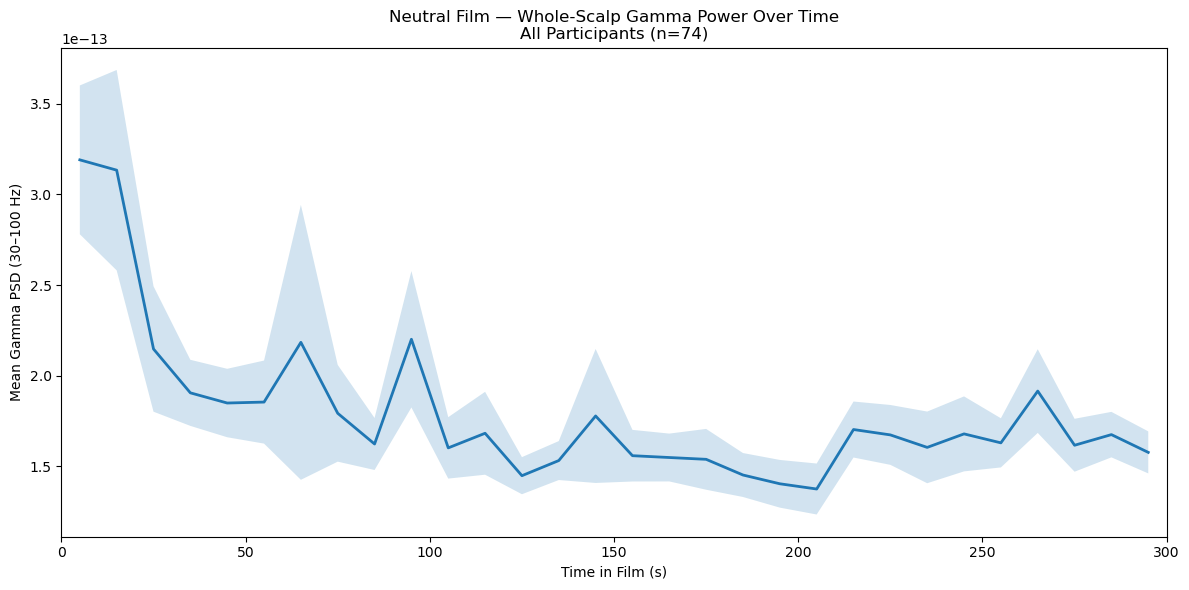

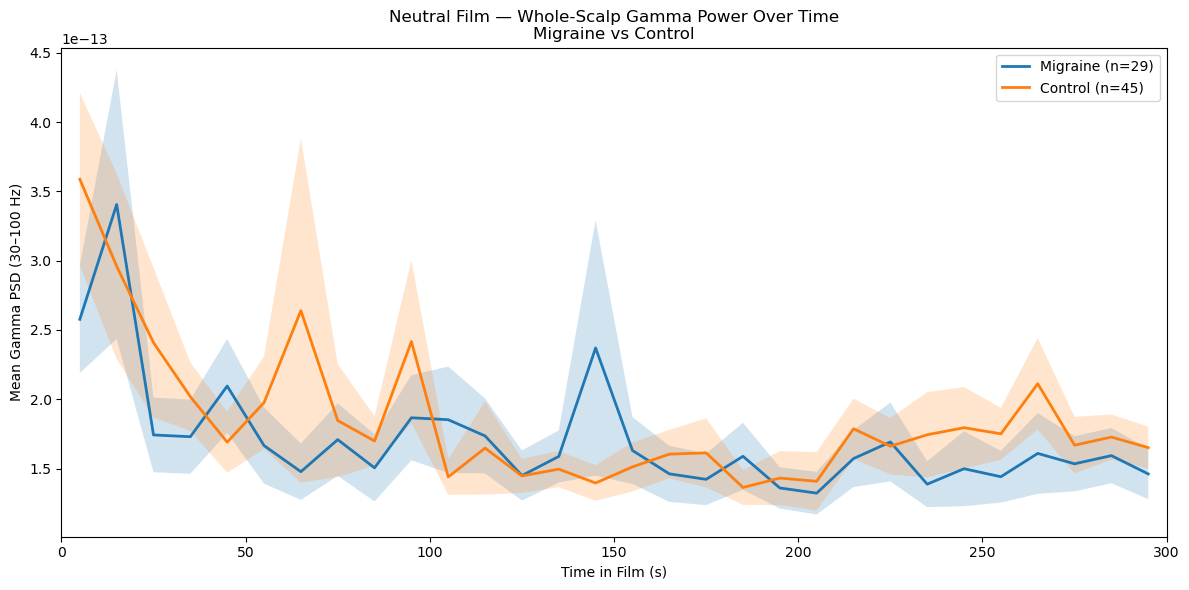

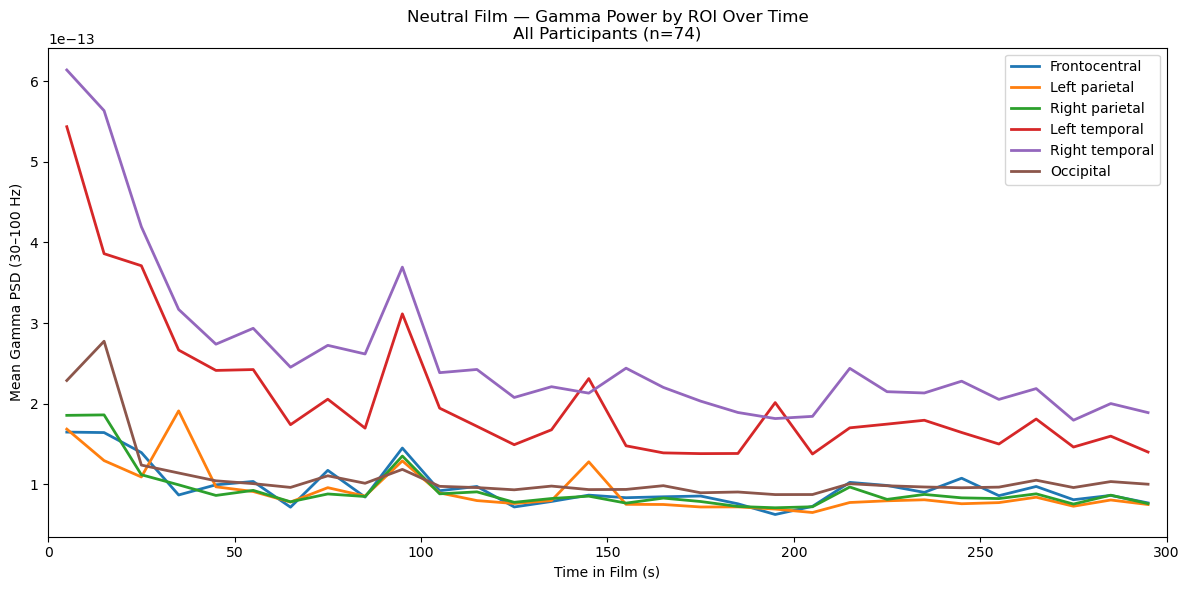

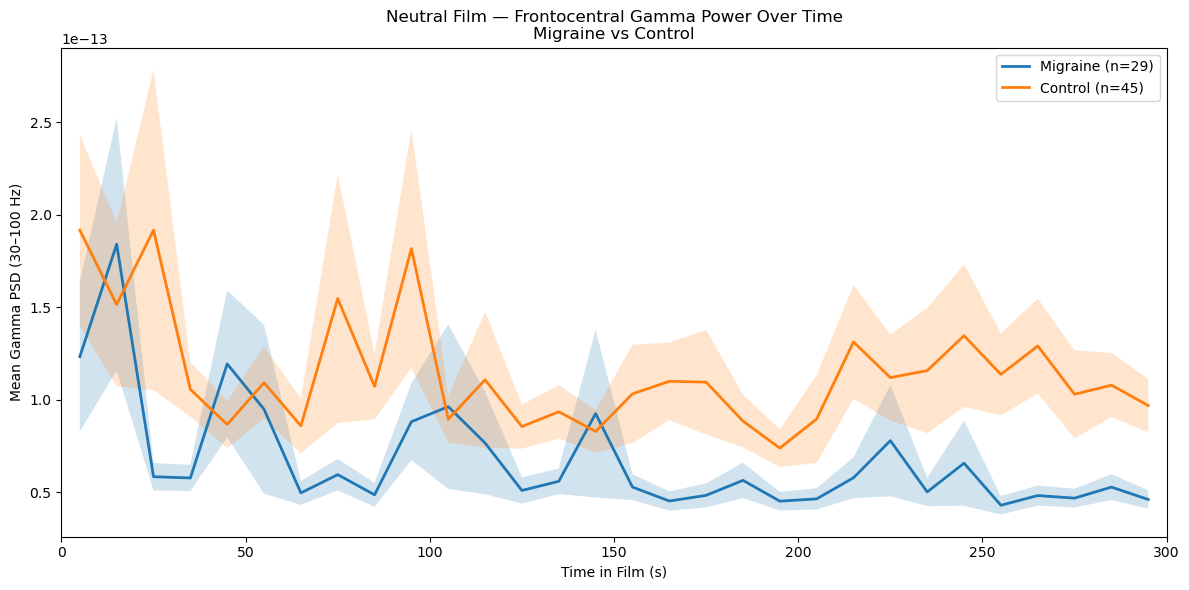

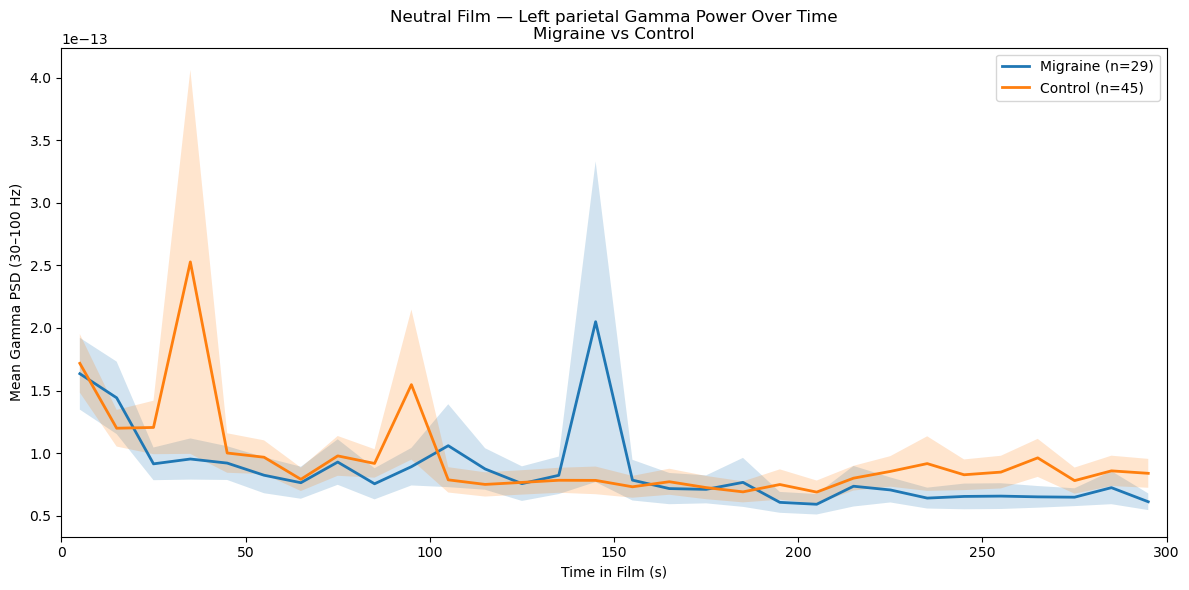

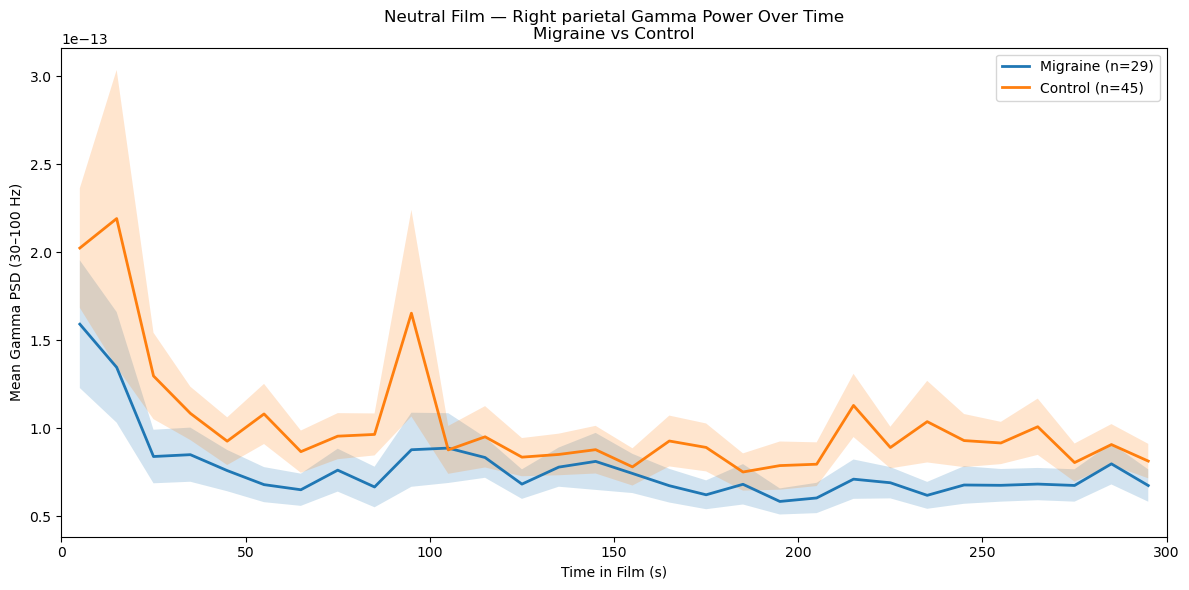

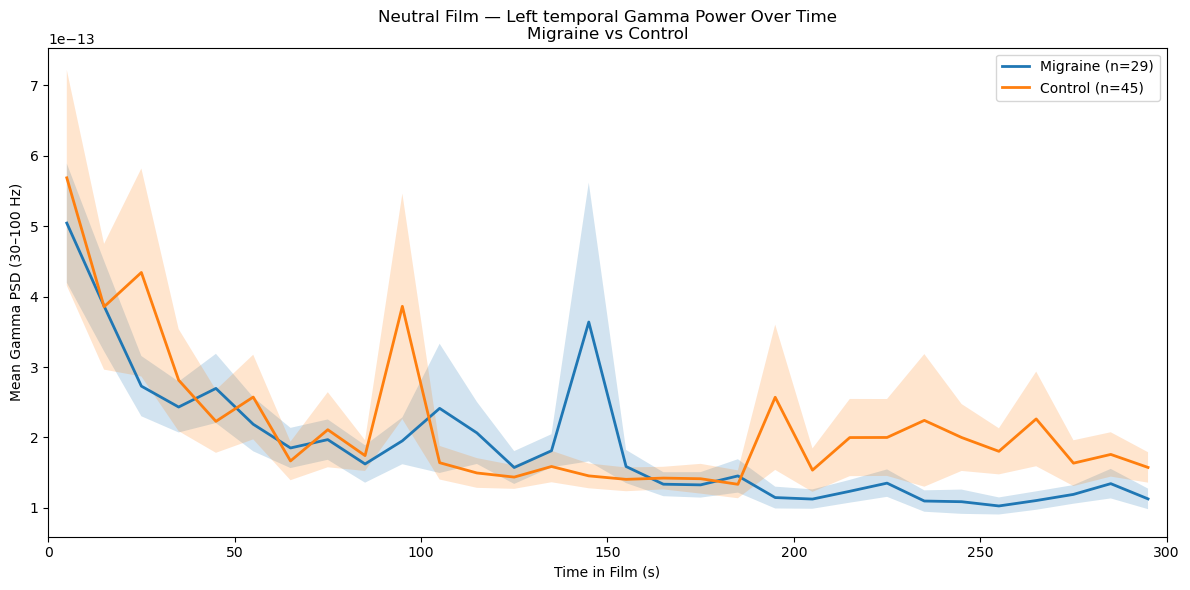

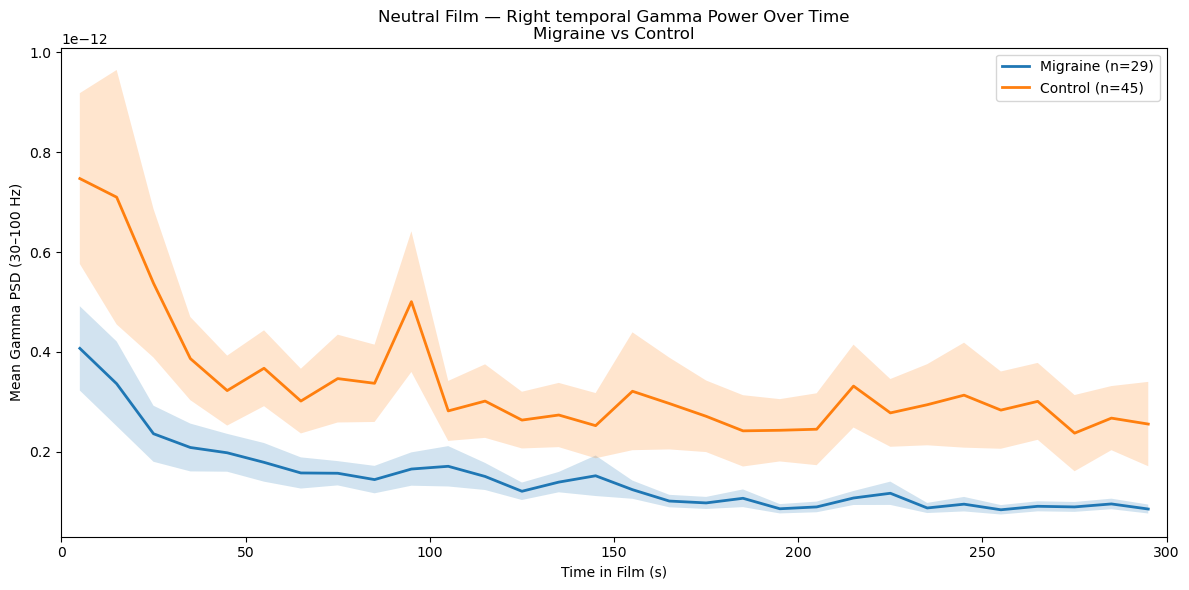

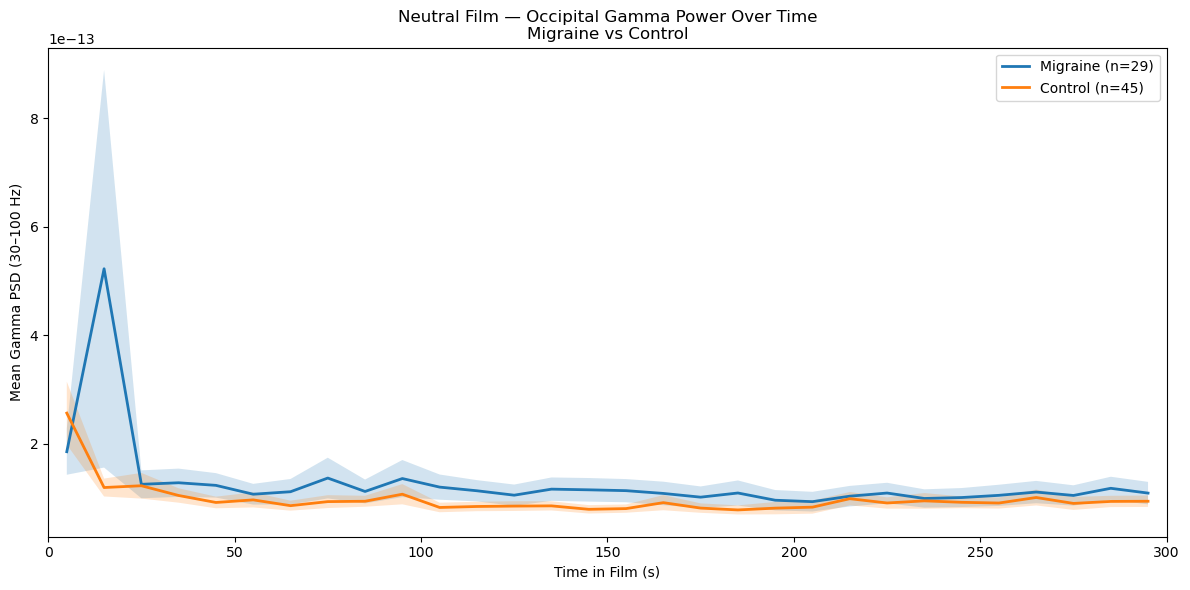

In [7]:
#see how gamma power changes over the time course of the film

BASE_DIR = Path("/media/ekstrandlab/eeg_backup/preprocessed/subjects")
DESKTOP = Path.home() / "Desktop"

TASK_CORE = "task-neutraltrainingvideo_eeg_fil01to100_notch60_seg_bcd"
PREFERRED = f"_{TASK_CORE}_bcr_reref_ICA.set"
FALLBACK = f"_{TASK_CORE}_reref_ICA.set"

BIN_SECONDS = 10

#Load neutral film

def pick_set(eeglab_dir, sub):
    preferred = eeglab_dir / f"{sub}{PREFERRED}"
    fallback = eeglab_dir / f"{sub}{FALLBACK}"

    if preferred.exists():
        return preferred
    if fallback.exists():
        return fallback
    return None

raw_dict = {}

for sub in group_a_subjects + group_b_subjects:
    eeglab_dir = BASE_DIR / sub / "eeglab2"
    in_set = pick_set(eeglab_dir, sub)

    if in_set is None:
        print(f"{sub}: no matching .set file found")
        continue

    raw_dict[sub] = mne.io.read_raw_eeglab(
        str(in_set),
        preload=True,
        verbose=False
    )

#Time bins

common_duration = min(raw.times[-1] for raw in raw_dict.values())
n_bins = int(np.floor(common_duration / BIN_SECONDS))

time_centres = (
    np.arange(n_bins) * BIN_SECONDS
    + BIN_SECONDS / 2
)

#Gamma power throughout film GAMMA POWER THROUGHOUT FILM

whole_gamma = {}
frontocentral_gamma = {}
left_parietal_gamma = {}
right_parietal_gamma = {}
left_temporal_gamma = {}
right_temporal_gamma = {}
occipital_gamma = {}

for sub, raw in raw_dict.items():

    sfreq = raw.info["sfreq"]

    n_per_seg = int(sfreq * 4)
    n_overlap = int(n_per_seg * 0.5)

    eeg_picks = mne.pick_types(
        raw.info,
        eeg=True,
        exclude="bads"
    )

    eeg_names = [raw.ch_names[p] for p in eeg_picks]

    frontocentral_idx = [
        eeg_names.index(ch)
        for ch in FRONTOCENTRAL_CHS
        if ch in eeg_names
    ]

    left_parietal_idx = [
        eeg_names.index(ch)
        for ch in LEFT_PARIETAL_CHS
        if ch in eeg_names
    ]

    right_parietal_idx = [
        eeg_names.index(ch)
        for ch in RIGHT_PARIETAL_CHS
        if ch in eeg_names
    ]

    left_temporal_idx = [
        eeg_names.index(ch)
        for ch in LEFT_TEMPORAL_CHS
        if ch in eeg_names
    ]

    right_temporal_idx = [
        eeg_names.index(ch)
        for ch in RIGHT_TEMPORAL_CHS
        if ch in eeg_names
    ]

    occipital_idx = [
        eeg_names.index(ch)
        for ch in OCCIPITAL_CHS
        if ch in eeg_names
    ]

    subject_whole = []
    subject_frontocentral = []
    subject_left_parietal = []
    subject_right_parietal = []
    subject_left_temporal = []
    subject_right_temporal = []
    subject_occipital = []

    for i in range(n_bins):

        segment = raw.copy().crop(
            tmin=i * BIN_SECONDS,
            tmax=(i + 1) * BIN_SECONDS,
            include_tmax=False
        )

        spectrum = segment.compute_psd(
            method="welch",
            fmin=30,
            fmax=100,
            n_fft=8192,
            n_per_seg=n_per_seg,
            n_overlap=n_overlap,
            window="hann",
            picks=eeg_picks,
            verbose=False
        )

        psd = spectrum.get_data()

        subject_whole.append(psd.mean())

        subject_frontocentral.append(
            psd[frontocentral_idx, :].mean()
        )

        subject_left_parietal.append(
            psd[left_parietal_idx, :].mean()
        )

        subject_right_parietal.append(
            psd[right_parietal_idx, :].mean()
        )

        subject_left_temporal.append(
            psd[left_temporal_idx, :].mean()
        )

        subject_right_temporal.append(
            psd[right_temporal_idx, :].mean()
        )

        subject_occipital.append(
            psd[occipital_idx, :].mean()
        )

    whole_gamma[sub] = np.array(subject_whole)
    frontocentral_gamma[sub] = np.array(subject_frontocentral)
    left_parietal_gamma[sub] = np.array(subject_left_parietal)
    right_parietal_gamma[sub] = np.array(subject_right_parietal)
    left_temporal_gamma[sub] = np.array(subject_left_temporal)
    right_temporal_gamma[sub] = np.array(subject_right_temporal)
    occipital_gamma[sub] = np.array(subject_occipital)

#Functions for plotting

def get_data(data, subjects):
    return np.array([
        data[sub]
        for sub in subjects
        if sub in data
    ])

def mean_sem(data):
    return (
        data.mean(axis=0),
        data.std(axis=0, ddof=1) / np.sqrt(data.shape[0])
    )

all_subjects = group_a_subjects + group_b_subjects

#Whole scalp- all participants

data = get_data(whole_gamma, all_subjects)
mean, sem = mean_sem(data)

plt.figure(figsize=(12, 6))

plt.plot(time_centres, mean, linewidth=2)

plt.fill_between(
    time_centres,
    mean - sem,
    mean + sem,
    alpha=0.2
)

plt.xlabel("Time in Film (s)")
plt.ylabel("Mean Gamma PSD (30–100 Hz)")

plt.title(
    f"Neutral Film — Whole-Scalp Gamma Power Over Time\n"
    f"All Participants (n={len(data)})"
)

plt.xlim(0, n_bins * BIN_SECONDS)
plt.tight_layout()

plt.savefig(
    DESKTOP / "Neutral_Gamma_WholeScalp_AllParticipants.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

#Whole scalp- migraine vs control

migraine = get_data(whole_gamma, group_a_subjects)
control = get_data(whole_gamma, group_b_subjects)

mig_mean, mig_sem = mean_sem(migraine)
con_mean, con_sem = mean_sem(control)

plt.figure(figsize=(12, 6))

plt.plot(
    time_centres,
    mig_mean,
    linewidth=2,
    label=f"Migraine (n={len(migraine)})"
)

plt.fill_between(
    time_centres,
    mig_mean - mig_sem,
    mig_mean + mig_sem,
    alpha=0.2
)

plt.plot(
    time_centres,
    con_mean,
    linewidth=2,
    label=f"Control (n={len(control)})"
)

plt.fill_between(
    time_centres,
    con_mean - con_sem,
    con_mean + con_sem,
    alpha=0.2
)

plt.xlabel("Time in Film (s)")
plt.ylabel("Mean Gamma PSD (30–100 Hz)")

plt.title(
    "Neutral Film — Whole-Scalp Gamma Power Over Time\n"
    "Migraine vs Control"
)

plt.xlim(0, n_bins * BIN_SECONDS)
plt.legend()
plt.tight_layout()

plt.savefig(
    DESKTOP / "Neutral_Gamma_WholeScalp_MigraineVsControl.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

#Each ROI- all participants

roi_data = {
    "Frontocentral": frontocentral_gamma,
    "Left parietal": left_parietal_gamma,
    "Right parietal": right_parietal_gamma,
    "Left temporal": left_temporal_gamma,
    "Right temporal": right_temporal_gamma,
    "Occipital": occipital_gamma
}

plt.figure(figsize=(12, 6))

for label, roi in roi_data.items():

    data = get_data(roi, all_subjects)
    mean, _ = mean_sem(data)

    plt.plot(
        time_centres,
        mean,
        linewidth=2,
        label=label
    )

plt.xlabel("Time in Film (s)")
plt.ylabel("Mean Gamma PSD (30–100 Hz)")

plt.title(
    f"Neutral Film — Gamma Power by ROI Over Time\n"
    f"All Participants (n={len(all_subjects)})"
)

plt.xlim(0, n_bins * BIN_SECONDS)
plt.legend()
plt.tight_layout()

plt.savefig(
    DESKTOP / "Neutral_Gamma_ROIs_AllParticipants.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

#Each ROI- migraine vs control

for label, roi in roi_data.items():

    migraine = get_data(roi, group_a_subjects)
    control = get_data(roi, group_b_subjects)

    mig_mean, mig_sem = mean_sem(migraine)
    con_mean, con_sem = mean_sem(control)

    plt.figure(figsize=(12, 6))

    plt.plot(
        time_centres,
        mig_mean,
        linewidth=2,
        label=f"Migraine (n={len(migraine)})"
    )

    plt.fill_between(
        time_centres,
        mig_mean - mig_sem,
        mig_mean + mig_sem,
        alpha=0.2
    )

    plt.plot(
        time_centres,
        con_mean,
        linewidth=2,
        label=f"Control (n={len(control)})"
    )

    plt.fill_between(
        time_centres,
        con_mean - con_sem,
        con_mean + con_sem,
        alpha=0.2
    )

    plt.xlabel("Time in Film (s)")
    plt.ylabel("Mean Gamma PSD (30–100 Hz)")

    plt.title(
        f"Neutral Film — {label} Gamma Power Over Time\n"
        "Migraine vs Control"
    )

    plt.xlim(0, n_bins * BIN_SECONDS)
    plt.legend()
    plt.tight_layout()

    plt.savefig(
        DESKTOP /
        f"Neutral_Gamma_{label.replace(' ', '')}_MigraineVsControl.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()